# Quick Start
Here’s a basic example of how to use **midlearn** to explain a trained LightGBM model, utilizing the familiar scikit-learn API.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import fetch_openml

import lightgbm as lgb
import midlearn as mid 

import plotnine as p9 # require plotnine >= 0.15.0
p9.theme_set(p9.theme_bw(base_family='serif'))

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


## 1. Train a Black-Box Model
We use the California Housing dataset to train a LightGBM Regressor, which will serve as our black-box model.

In [2]:
# Load and prepare data
bikeshare = fetch_openml(data_id=42712)
X = pd.DataFrame(bikeshare.data, columns=bikeshare.feature_names)
y = bikeshare.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Fit a LightGBM regression model
estimator = lgb.LGBMRegressor(
    force_col_wise=True,
    n_estimators=500,
    random_state=42
)
estimator.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 283
[LightGBM] [Info] Number of data points in the train set: 13034, number of used features: 12
[LightGBM] [Info] Start training from score 190.379623


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [3]:
model_pred = estimator.predict(X_test)
rmse = root_mean_squared_error(model_pred, y_test)
print(f"RMSE: {round(rmse, 6)}")

RMSE: 37.615267


## 2. Create an Explaination Model
We fit the `MIDExplainer` to the training data to create a globally faithful, interpretable surrogate model (MID).

In [4]:
# Initialize and fit the MID model
explainer = mid.MIDExplainer(
    estimator=estimator,
    penalty=.05,
    singular_ok=True,
    interactions=True,
    encoding_frames={'hour':list(range(24))}
)
explainer.fit(X_train)

Generating predictions from the estimator...


R callback write-console: singular fit encountered
  


,estimator,LGBMRegressor...ndom_state=42)
,target_classes,None
,params_main,None
,params_inter,None
,penalty,0.05
,link,None
,kernel_type,1
,encoding_frames,"{'hour': [0, 1, ...]}"
,model_terms,None
,singular_ok,True
,mode,1


Generating predictions from the estimator...


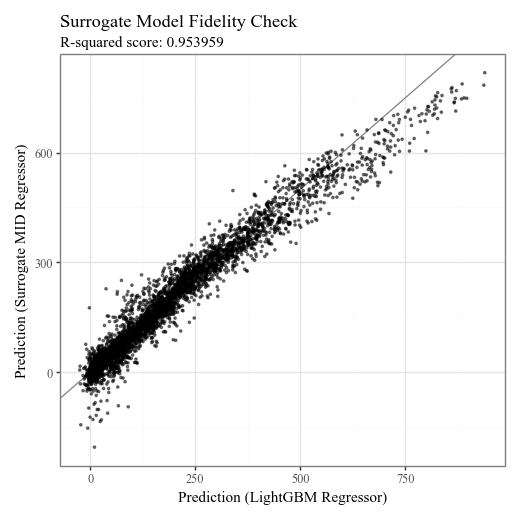

In [5]:
# Check the fidelity of the surrogate model to the original model
p = p9.ggplot() \
    + p9.geom_abline(slope=1, color='gray') \
    + p9.geom_point(p9.aes(estimator.predict(X_test), explainer.predict(X_test)), alpha=0.5, shape=".") \
    + p9.labs(
        x='Prediction (LightGBM Regressor)',
        y='Prediction (Surrogate MID Regressor)',
        title='Surrogate Model Fidelity Check',
        subtitle=f'R-squared score: {round(explainer.fidelity_score(X_test), 6)}',
    )
display(p + p9.theme(figure_size=(5,5)))

## 3. Visualize the Explanation Model
The MID model allows for clear visualization of feature importance, individual effects, and local prediction breakdowns.

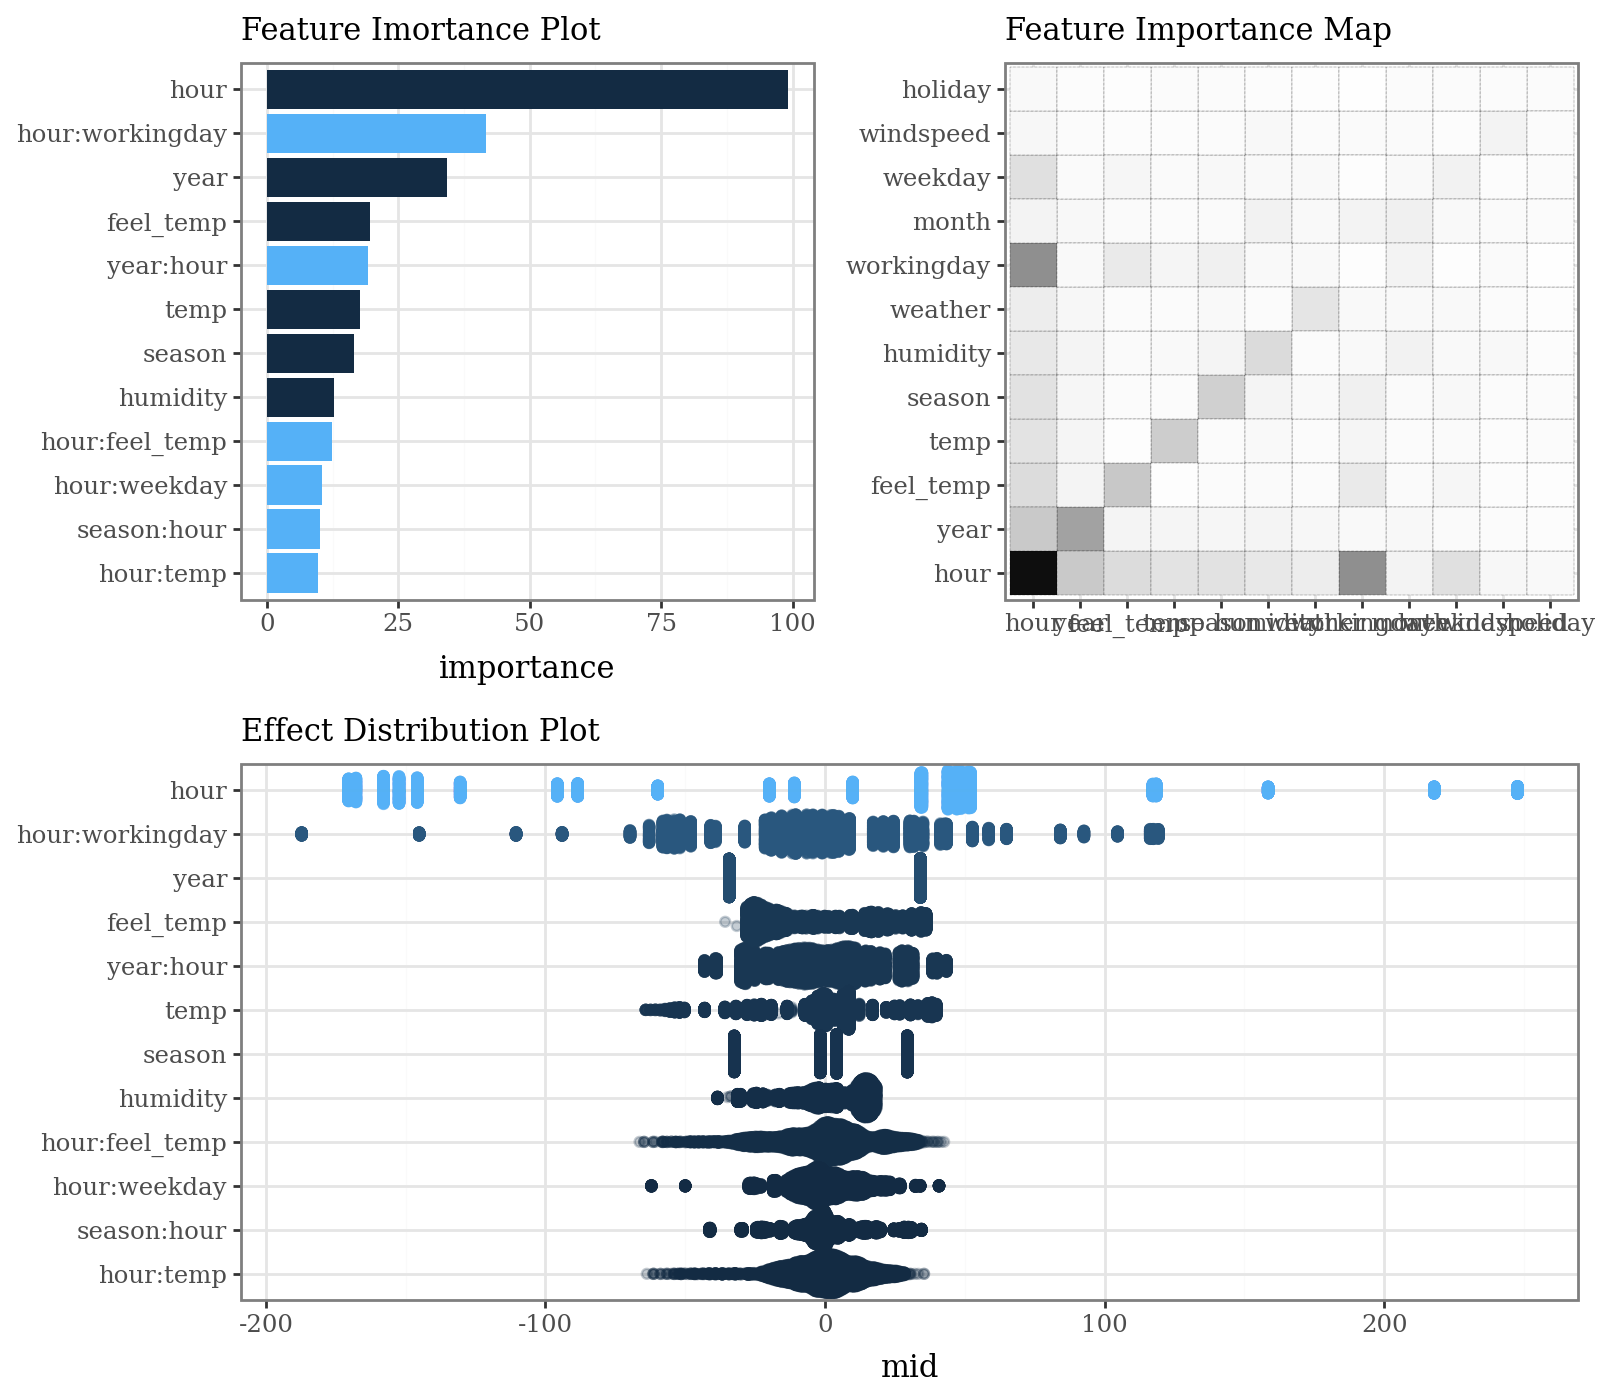

In [18]:
# Calculate and plot overall feature importance (default bar plot and heatmap)
imp = explainer.importance()
p1 = (
    imp.plot(max_nterms=12, theme = 'bluescale@qual') +
    p9.labs(subtitle="Feature Imortance Plot") +
    p9.coord_flip()
)
p2 = (
    imp.plot(style='heatmap', color='black', linetype='dotted') +
    p9.labs(subtitle="Feature Importance Map")
)
p3 = (
    imp.plot(max_nterms=12, theme="bluescale", alpha = .25, style='sina') +
    p9.labs(subtitle="Effect Distribution Plot")
)
display(((p1 | p2) / p3) & p9.theme(figure_size=(8, 7), legend_position="none"))

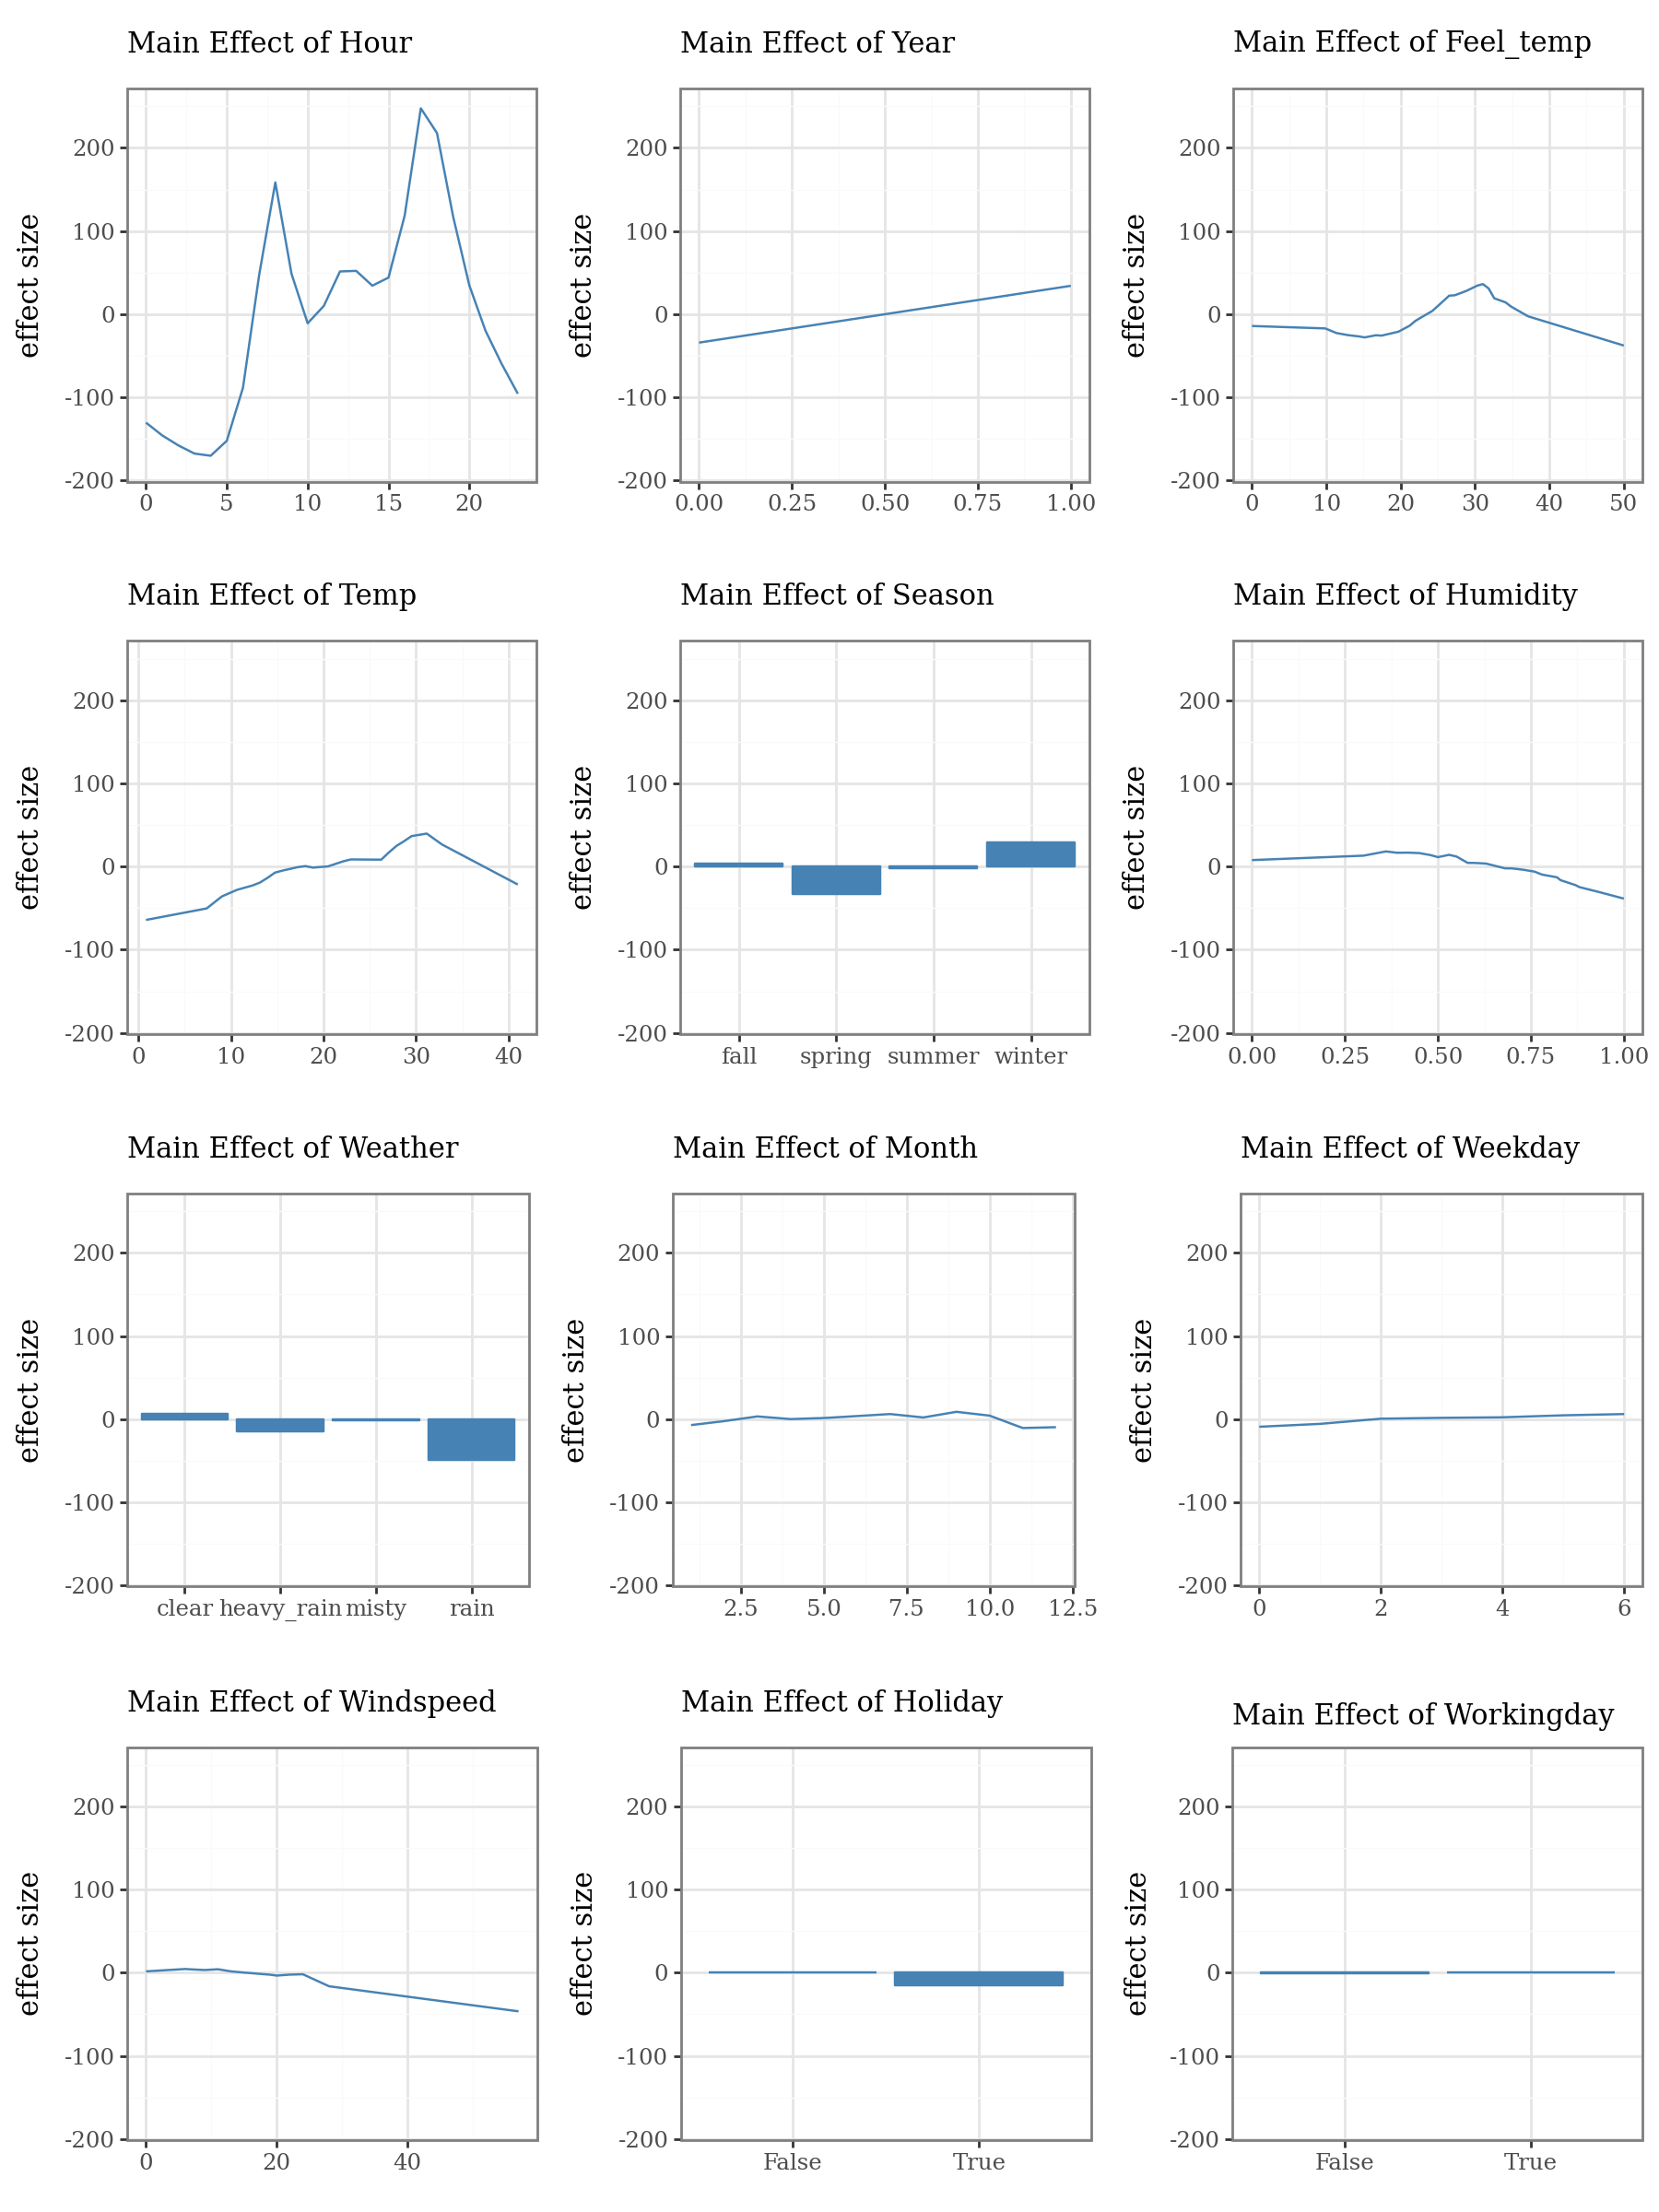

In [16]:
# Plot the top 3 important main effects (Component Functions)
plots = list()
for i, t in enumerate(imp.terms(interactions=False)):
    p = (
        explainer.plot(term=t, color="steelblue", fill="steelblue", linewidth=1) +
        p9.lims(y=[-180, 250]) +
        p9.labs(
            subtitle=f"Main Effect of {t.capitalize()}",
            x="",
            y="effect size"
        )
    )
    plots.append(p)

p1 = (
    (plots[0] | plots[1] | plots[2]) /
    (plots[3] | plots[4] | plots[5]) /
    (plots[6] | plots[7] | plots[8]) /
    (plots[9] | plots[10] | plots[11])
)
display(p1 + p9.theme(figure_size=(9, 12)))

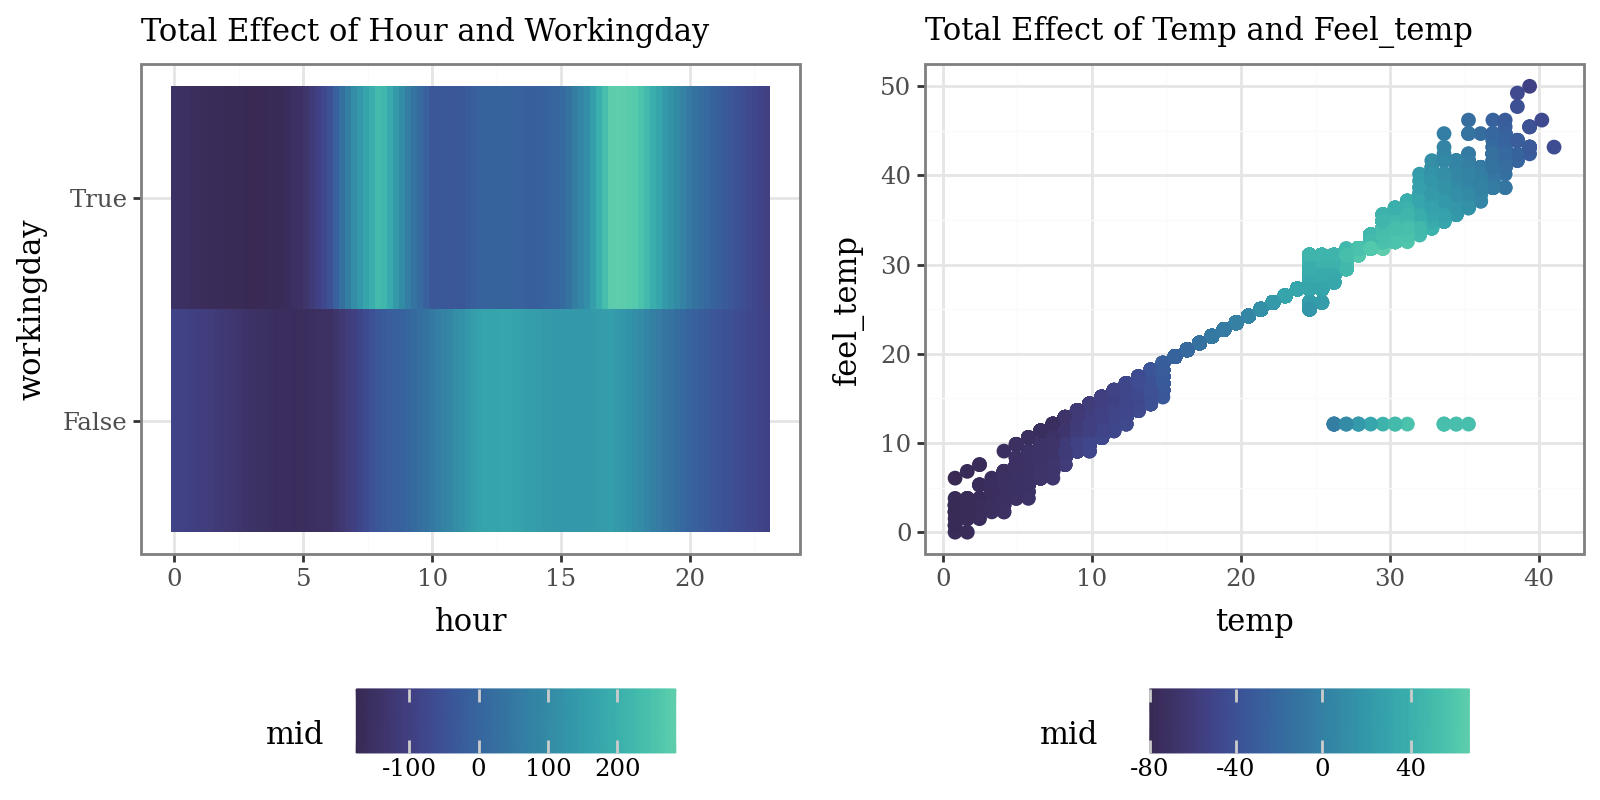

In [19]:
# Plot the interaction of pairs of variables (Component Functions)
p1 = (
    explainer.plot(
        "hour:workingday",
        theme='mako',
        main_effects=True
    ) +
    p9.labs(subtitle="Total Effect of Hour and Workingday")
)
p2 = (
    explainer.plot(
        "temp:feel_temp",
        style='data',
        theme='mako',
        data=X_train,
        main_effects=True,
        size=2
    ) +
    p9.labs(subtitle="Total Effect of Temp and Feel_temp")
)
display((p1 | p2) & p9.theme(figure_size=(8, 4), legend_position="bottom"))

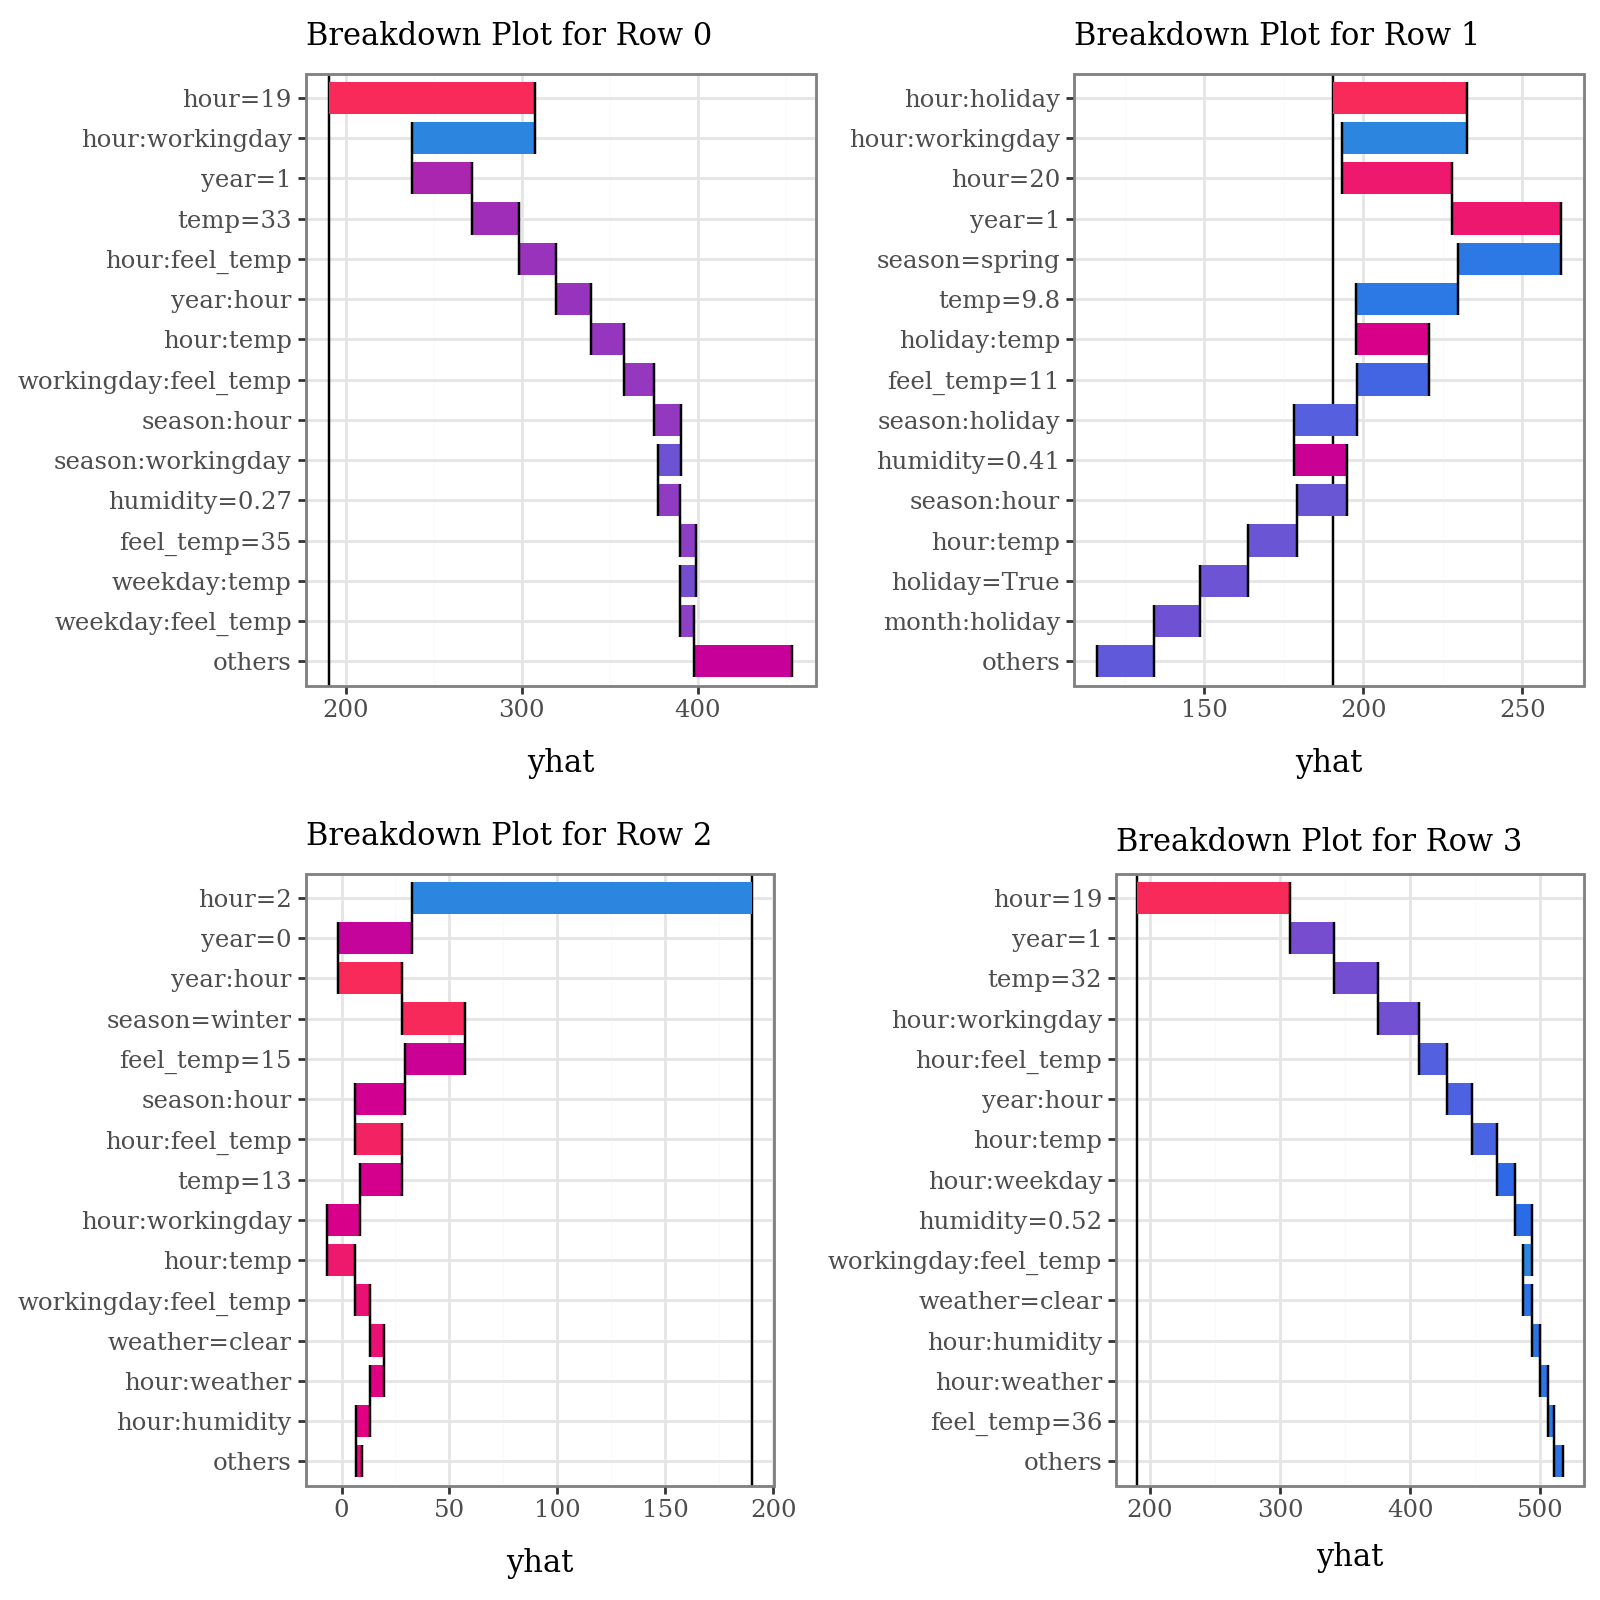

In [13]:
# Plot prediction breakdowns for the first three test samples (Local Interpretability)
plots = list()
for i in range(4):
    p = (
        explainer.breakdown(row=i, data=X_test)
        .plot(format_args = {'digits': 2}, theme="shap") +
        p9.theme(legend_position="none") +
        p9.labs(subtitle=f"Breakdown Plot for Row {i}")
    )
    plots.append(p)

p1 = (
    (plots[0] | plots[1]) /
    (plots[2] | plots[3])
)
display(p1 + p9.theme(figure_size=(8, 8)))

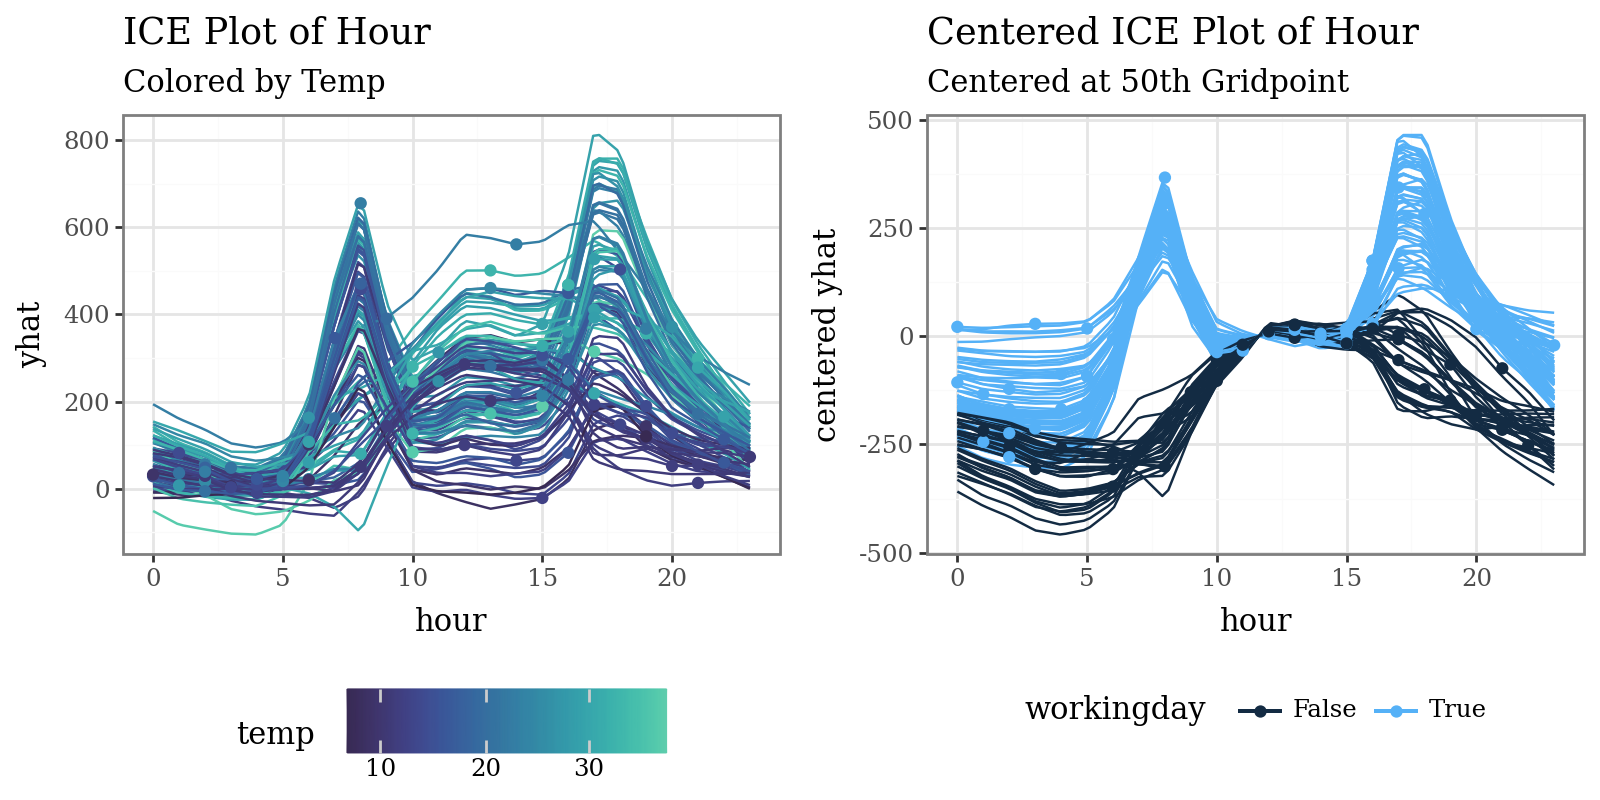

In [25]:
# Plot individual conditional expectations (ICE) with color encoding
ice = explainer.conditional(
    variable='hour',
    data=X_train.head(100)
)
p1 = (
    ice.plot(var_color='temp', theme='mako') +
    p9.labs(
        title="ICE Plot of Hour",
        subtitle="Colored by Temp"
    )
)
p2 = (
    ice.plot(
        style='centered',
        var_color='workingday',
        theme='bluescale@qual',
        reference=50
    ) +
    p9.labs(
        title="Centered ICE Plot of Hour",
        subtitle="Centered at 50th Gridpoint"
    ) +
    p9.theme(legend_position="bottom")
)
display((p1 | p2) & p9.theme(figure_size=(8, 4), legend_position="bottom"))

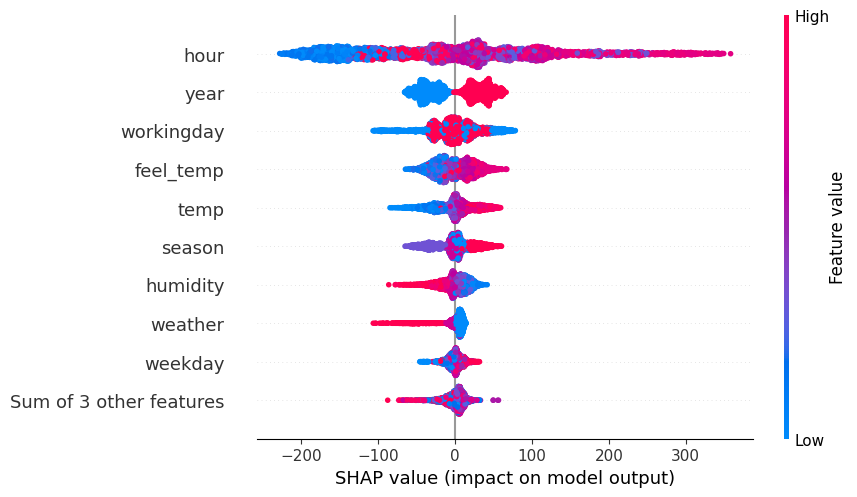

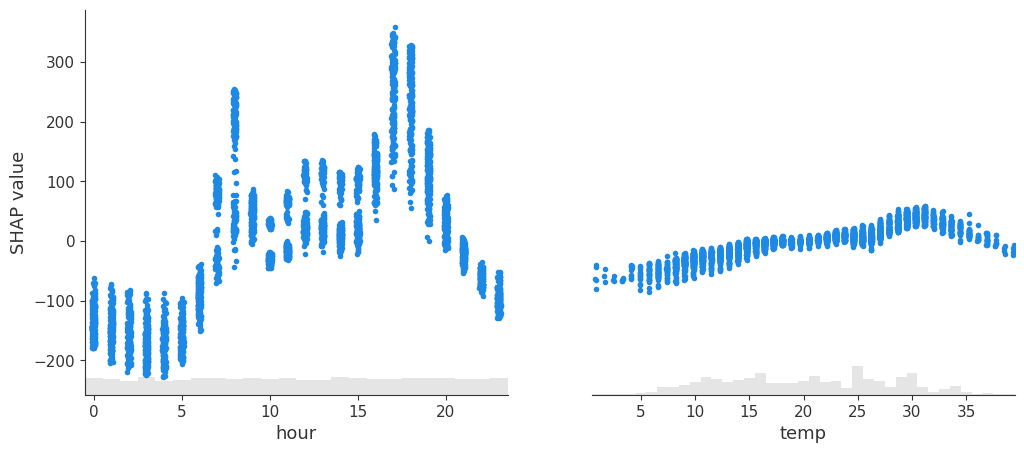

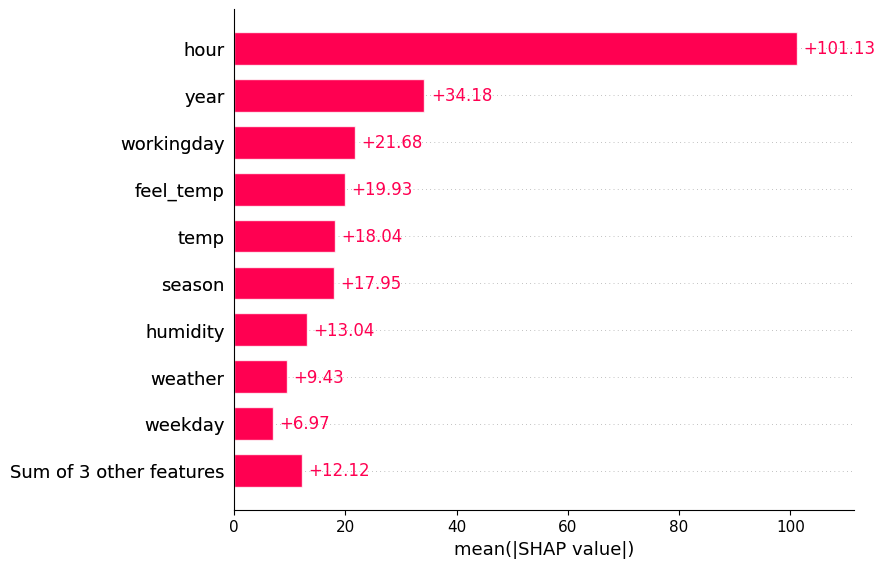

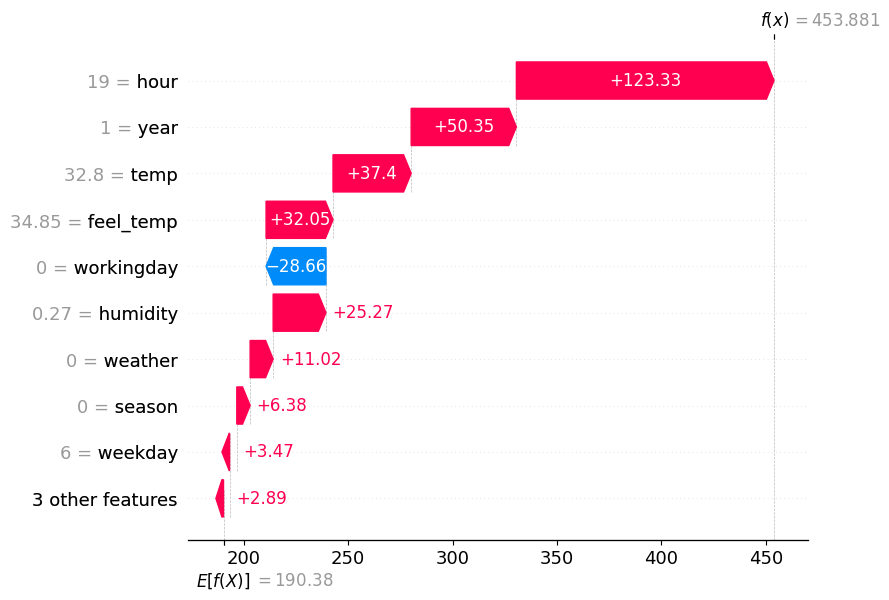

In [26]:
# Plot MID-derived Shapley explanations ('shap' library required)
spv = explainer.shapley(data=X_test)
spv.plot(style='beeswarm')
spv.plot(style='scatter', variables=["hour", "temp"])
spv.plot(style='barplot')
spv.plot(style='waterfall', instances=0)
